In [8]:
import numpy as np

np.int = int

In [44]:
import configparser
configparser.SafeConfigParser = configparser.ConfigParser

In [45]:
import pylidc as pl

In [9]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

caminho_volume = Path("/home/ana/PycharmProjects/Visao_Computacional/presentation2/volume.mhd")

print("Arquivo existe?", caminho_volume.exists())

img = sitk.ReadImage(str(caminho_volume))
volume = sitk.GetArrayFromImage(img)

print("Shape do volume:", volume.shape)
print("Valor mínimo:", volume.min())
print("Valor máximo:", volume.max())
print("Valor médio:", volume.mean())

Arquivo existe? True
Shape do volume: (133, 512, 512)
Valor mínimo: -2048
Valor máximo: 3071
Valor médio: -826.9439289121699


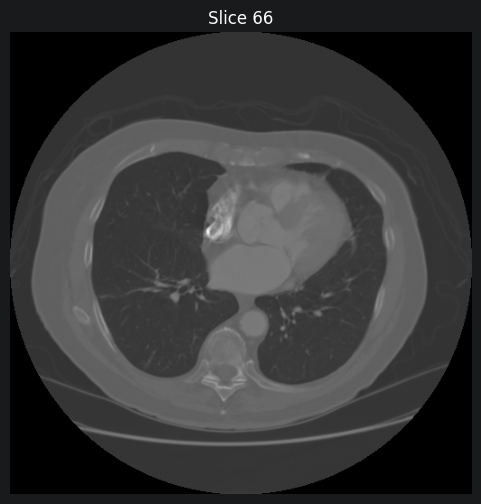

In [2]:
slice_idx = volume.shape[0] // 2

plt.figure(figsize=(6,6))
plt.imshow(volume[slice_idx], cmap="gray")
plt.title(f"Slice {slice_idx}")
plt.axis("off")
plt.show()

In [3]:
mask_img = sitk.ReadImage(
    "/home/ana/PycharmProjects/Visao_Computacional/presentation2/rt6.mhd"
)

mask = sitk.GetArrayFromImage(mask_img)

print("Shape da máscara:", mask.shape)
print("Valores únicos:", np.unique(mask))
print("Soma da máscara:", np.sum(mask))

Shape da máscara: (133, 512, 512)
Valores únicos: [  0 255]
Soma da máscara: 692216880


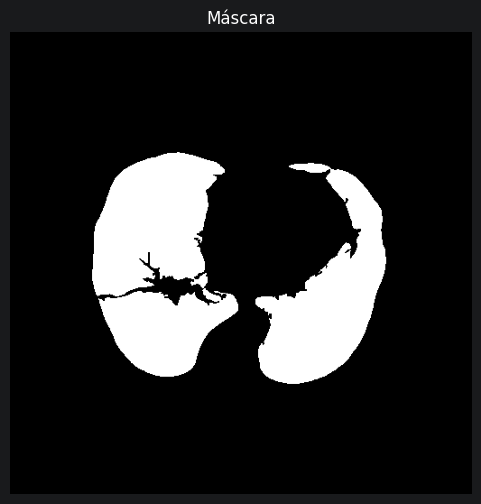

In [4]:
slice_idx = 66

plt.figure(figsize=(6,6))
plt.imshow(mask[slice_idx], cmap="gray")
plt.title("Máscara")
plt.axis("off")
plt.show()

In [5]:
import pylidc as pl

scans = pl.query(pl.Scan).all()

print("Número de exames:", len(scans))

Número de exames: 1018


In [6]:
scan = scans[0]

print("Paciente:", scan.patient_id)
print("Número de anotações:", len(scan.annotations))

Paciente: LIDC-IDRI-0078
Número de anotações: 13


In [11]:
ann = scan.annotations[0]

print("Malignidade:", ann.malignancy)
print("Centroide:", ann.centroid)
print("Diâmetro:", ann.diameter)

Malignidade: 3
Centroide: [169.19642857 360.81122449  46.20153061]
Diâmetro: 20.84058540444583


In [12]:
for i, ann in enumerate(scan.annotations):
    print(
        i,
        "Malignidade:", ann.malignancy,
        "Centroide:", ann.centroid
    )


0 Malignidade: 3 Centroide: [169.19642857 360.81122449  46.20153061]
1 Malignidade: 3 Centroide: [312.30982368 331.90680101  25.64987406]
2 Malignidade: 4 Centroide: [245.07692308 340.54020979  67.5472028 ]
3 Malignidade: 5 Centroide: [244.65275708 341.29061103  67.46944858]
4 Malignidade: 4 Centroide: [169.21319797 360.82233503  46.21573604]
5 Malignidade: 4 Centroide: [309.91796875 328.60546875  25.41015625]
6 Malignidade: 5 Centroide: [244.03490137 341.75417299  67.81942337]
7 Malignidade: 1 Centroide: [348.83333333 336.41666667  47.41666667]
8 Malignidade: 5 Centroide: [168.86142322 361.05243446  46.28089888]
9 Malignidade: 5 Centroide: [309.88293651 327.91666667  25.17261905]
10 Malignidade: 3 Centroide: [245.58532695 341.53110048  67.66666667]
11 Malignidade: 3 Centroide: [171.         361.25501433  46.43553009]
12 Malignidade: 3 Centroide: [313.88050314 332.55660377  25.48113208]


In [13]:
clusters = scan.cluster_annotations()

print("Número de nódulos:", len(clusters))

Número de nódulos: 4


In [14]:
for i, cluster in enumerate(clusters):
    print(f"\nNódulo {i}")

    for ann in cluster:
        print(
            "Malignidade:",
            ann.malignancy
        )


Nódulo 0
Malignidade: 3
Malignidade: 4
Malignidade: 5
Malignidade: 3

Nódulo 1
Malignidade: 3
Malignidade: 4
Malignidade: 5
Malignidade: 3

Nódulo 2
Malignidade: 1

Nódulo 3
Malignidade: 4
Malignidade: 5
Malignidade: 5
Malignidade: 3


In [15]:
def obter_rotulo_cenario4(cluster):
    malignidades = [ann.malignancy for ann in cluster]

    # remove os 3
    malignidades = [m for m in malignidades if m != 3]

    if len(malignidades) == 0:
        return None

    classes = []

    for m in malignidades:
        if m in [1, 2]:
            classes.append("benigno")
        elif m in [4, 5]:
            classes.append("maligno")

    if len(set(classes)) == 1:
        return classes[0]

    return None

In [16]:
for i, cluster in enumerate(clusters):
    print(
        f"Nódulo {i}:",
        obter_rotulo_cenario4(cluster)
    )

Nódulo 0: maligno
Nódulo 1: maligno
Nódulo 2: benigno
Nódulo 3: maligno


In [17]:
cluster = clusters[0]

centroide = np.mean(
    [ann.centroid for ann in cluster],
    axis=0
)

print("Centroide:", centroide)

Centroide: [311.49780802 330.24638505  25.42844536]


In [21]:
x, y, z = centroide.astype(int)

tamanho = 32

patch = volume[
    max(0, z - tamanho):min(volume.shape[0], z + tamanho),
    max(0, y - tamanho):min(volume.shape[1], y + tamanho),
    max(0, x - tamanho):min(volume.shape[2], x + tamanho)
]

print("Shape do patch:", patch.shape)
print("Min:", patch.min())
print("Max:", patch.max())

Shape do patch: (57, 64, 64)
Min: -996
Max: 1298


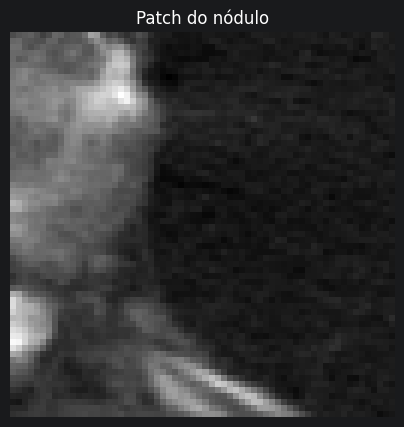

In [22]:
slice_central = patch.shape[0] // 2

plt.figure(figsize=(5,5))
plt.imshow(
    patch[slice_central],
    cmap="gray"
)
plt.title("Patch do nódulo")
plt.axis("off")
plt.show()

In [20]:
print(
    "Rótulo:",
    obter_rotulo_cenario4(cluster)
)

for ann in cluster:
    print(
        "Malignidade:",
        ann.malignancy,
        "Centroide:",
        ann.centroid,
        "Diâmetro:",
        ann.diameter
    )

Rótulo: maligno
Malignidade: 3 Centroide: [312.30982368 331.90680101  25.64987406] Diâmetro: 19.500000000000007
Malignidade: 4 Centroide: [309.91796875 328.60546875  25.41015625] Diâmetro: 27.653661602037456
Malignidade: 5 Centroide: [309.88293651 327.91666667  25.17261905] Diâmetro: 27.980216225040127
Malignidade: 3 Centroide: [313.88050314 332.55660377  25.48113208] Diâmetro: 20.647094226549182


In [23]:
scans_teste = scans[:20]
print(len(scans_teste))

20


In [25]:
dados = []

In [26]:
for scan in scans_teste:

    clusters = scan.cluster_annotations()

    for cluster in clusters:

        rotulo = obter_rotulo_cenario4(cluster)

        if rotulo is None:
            continue

        centroide = np.mean(
            [ann.centroid for ann in cluster],
            axis=0
        )

        x, y, z = centroide.astype(int)

        dados.append({
            "paciente": scan.patient_id,
            "x": x,
            "y": y,
            "z": z,
            "rotulo": rotulo
        })

In [27]:
import pandas as pd

df = pd.DataFrame(dados)

print(df.shape)
df.head()

(37, 5)


,paciente,x,y,z,rotulo
0,LIDC-IDRI-0078,311,330,25,maligno
1,LIDC-IDRI-0078,169,360,46,maligno
2,LIDC-IDRI-0078,348,336,47,benigno
3,LIDC-IDRI-0078,244,341,67,maligno
4,LIDC-IDRI-0069,339,226,52,benigno


In [28]:
linha = df.iloc[0]
linha

paciente    LIDC-IDRI-0078
x                      311
y                      330
z                       25
rotulo             maligno
Name: 0, dtype: object

In [29]:
x = int(linha["x"])
y = int(linha["y"])
z = int(linha["z"])

tamanho = 16

patch = volume[
    max(0, z-tamanho):min(volume.shape[0], z+tamanho),
    max(0, y-tamanho):min(volume.shape[1], y+tamanho),
    max(0, x-tamanho):min(volume.shape[2], x+tamanho)
]

print(patch.shape)

(32, 32, 32)


In [30]:
features = {}

features["mean"] = patch.mean()
features["std"] = patch.std()
features["min"] = patch.min()
features["max"] = patch.max()
features["median"] = np.median(patch)
features["p25"] = np.percentile(patch, 25)
features["p75"] = np.percentile(patch, 75)

features

{'mean': np.float64(-76.33224487304688),
 'std': np.float64(181.07790168145314),
 'min': np.int32(-935),
 'max': np.int32(857),
 'median': np.float64(-84.0),
 'p25': np.float64(-114.0),
 'p75': np.float64(21.0)}

In [40]:
def extrair_features(volume, x, y, z, tamanho=16):

    z1 = max(0, z - tamanho)
    z2 = min(volume.shape[0], z + tamanho)

    y1 = max(0, y - tamanho)
    y2 = min(volume.shape[1], y + tamanho)

    x1 = max(0, x - tamanho)
    x2 = min(volume.shape[2], x + tamanho)

    patch = volume[z1:z2, y1:y2, x1:x2]

    if patch.size == 0:
        return None

    f = {}

    f["mean"] = patch.mean()
    f["std"] = patch.std()
    f["min"] = patch.min()
    f["max"] = patch.max()
    f["median"] = np.median(patch)
    f["p25"] = np.percentile(patch, 25)
    f["p75"] = np.percentile(patch, 75)

    return f

In [41]:
dados_features = []

for _, linha in df_paciente.iterrows():

    x = int(linha["x"])
    y = int(linha["y"])
    z = int(linha["z"])

    f = extrair_features(
        volume,
        x,
        y,
        z
    )

    if f is None:
        continue

    f["rotulo"] = linha["rotulo"]

    dados_features.append(f)

In [35]:
df_paciente = df[
    df["paciente"] == scan.patient_id
]

print(df_paciente)

          paciente    x    y    z   rotulo
35  LIDC-IDRI-0009  334  201  102  benigno
36  LIDC-IDRI-0009  324  303  166  benigno


In [36]:
print(scan.patient_id)

LIDC-IDRI-0009


In [37]:
for i in range(10):
    print(i, scans[i].patient_id)

0 LIDC-IDRI-0078
1 LIDC-IDRI-0069
2 LIDC-IDRI-0079
3 LIDC-IDRI-0101
4 LIDC-IDRI-0110
5 LIDC-IDRI-0115
6 LIDC-IDRI-0132
7 LIDC-IDRI-0136
8 LIDC-IDRI-0150
9 LIDC-IDRI-0151


In [38]:
print(volume.shape)

(133, 512, 512)


In [39]:
print(scan.patient_id)
print(volume.shape)

LIDC-IDRI-0009
(133, 512, 512)


In [42]:
df_features = pd.DataFrame(dados_features)

print(df_features.shape)
df_features

(1, 8)


,mean,std,min,max,median,p25,p75,rotulo
0,-681.669037,378.731138,-1024,451,-887.0,-916.0,-640.0,benigno


In [43]:
scan = scans[0]

volume_scan = scan.to_volume()

print(scan.patient_id)
print(volume_scan.shape)

Loading dicom files ... This may take a moment.


AttributeError: module 'configparser' has no attribute 'SafeConfigParser'